In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

In [2]:
df = pd.read_csv(r"O:\ITI\DSets\Netflix\netflix_titles.csv")
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB


In [4]:
#find null percentage for each column
for i in df.columns:
    null_percentage = df[i].isna().sum() / len(df[i]) * 100
    if null_percentage > 0:
        print(f"{i} null percentage: {round((null_percentage), 2)}%")

director null percentage: 29.91%
cast null percentage: 9.37%
country null percentage: 9.44%
date_added null percentage: 0.11%
rating null percentage: 0.05%
duration null percentage: 0.03%



6 column out of 12 have missing values, director column has the highest null percentage 30% of the data is missing

- director column cant be filled manually we can later inject data from the main data source or map it later from other source based on what is best, but now we will keep is as it is.
- cast column is the same case as the director
- country is lower percentage so we can impute with the most common country untill we go back to the data source.
- rating is much lower we can drop the nulls
- duration and date_added same as rating


In [5]:

most_common_country = df['country'].mode()[0]
most_common_country

'United States'

In [6]:
#director & cast null handling
df['director'] = df['director'].replace(np.nan, 'No Data')
df['cast'] = df['cast'].replace(np.nan, 'No Data')

# country nulls replacement 
df['country'] =  df['country'].fillna(most_common_country)

#droping the rest
df.dropna(subset=['rating'], inplace=True)
df.dropna(subset=['duration'], inplace=True)
df.dropna(subset=['date_added'], inplace=True)


In [7]:
df.duplicated().sum()  #no duplicates found

np.int64(0)

In [8]:
df.isna().sum()

show_id         0
type            0
title           0
director        0
cast            0
country         0
date_added      0
release_year    0
rating          0
duration        0
listed_in       0
description     0
dtype: int64

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 8790 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8790 non-null   object
 1   type          8790 non-null   object
 2   title         8790 non-null   object
 3   director      8790 non-null   object
 4   cast          8790 non-null   object
 5   country       8790 non-null   object
 6   date_added    8790 non-null   object
 7   release_year  8790 non-null   int64 
 8   rating        8790 non-null   object
 9   duration      8790 non-null   object
 10  listed_in     8790 non-null   object
 11  description   8790 non-null   object
dtypes: int64(1), object(11)
memory usage: 892.7+ KB


In [10]:
df['date_added'] = df['date_added'].str.strip()
df['date_added'] = pd.to_datetime(df['date_added'])

In [11]:
#movies percentage to tv shows
x = df.groupby(['type'])['type'].count()
percentage = x / len(df)
percentage

type
Movie      0.696928
TV Show    0.303072
Name: type, dtype: float64

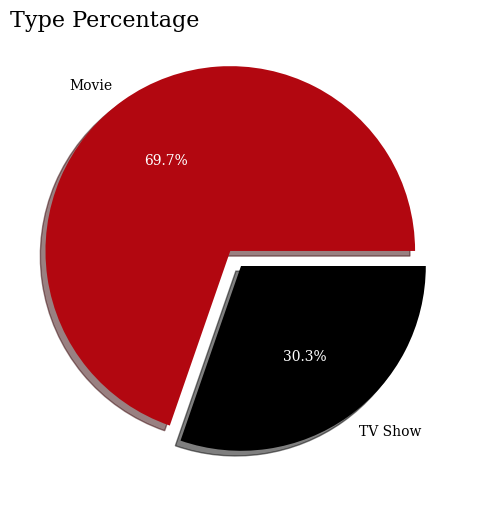

In [12]:
plt.figure(figsize=(8, 6))
labels=percentage.index
_, _, autotexts = plt.pie(percentage,labels=percentage.index, autopct='%1.1f%%', 
                          colors=['#b20710', '#000000'], 
                          explode=[0.1, 0], shadow=True,
                          textprops={'color':'#000000', 'fontfamily':'serif'})

for a in autotexts:
    a.set_color('white')
    a.set_fontfamily('serif')


plt.title("Type Percentage",fontsize=16, loc='left', fontfamily='serif', color='#000000')
plt.show()

- Insights:
  - 70% of Netflix production is movies
  

In [13]:
country_content = df.groupby('country')['type'].value_counts()
country_content
# we have more than 800 hundrend value due to countries contributed together in 1 type interpreted a new country 
# so we will show the top 10 only and the rest will be together

country                                              type   
, France, Algeria                                    Movie       1
, South Korea                                        TV Show     1
Argentina                                            Movie      38
                                                     TV Show    18
Argentina, Brazil, France, Poland, Germany, Denmark  Movie       1
                                                                ..
Venezuela                                            Movie       1
Venezuela, Colombia                                  Movie       1
Vietnam                                              Movie       7
West Germany                                         Movie       1
Zimbabwe                                             Movie       1
Name: count, Length: 847, dtype: int64

In [14]:
#top 10 countries count values
top_10 = df['country'].value_counts().head(10).index
top_10

Index(['United States', 'India', 'United Kingdom', 'Japan', 'South Korea',
       'Canada', 'Spain', 'France', 'Mexico', 'Egypt'],
      dtype='object', name='country')

In [15]:
df['countries_grouped']= df['country'].apply(lambda x: x if x in top_10 else 'Others')
df['countries_grouped']
#new column to show top 10 countries and the rest will be assigned to others

0       United States
1              Others
2       United States
3       United States
4               India
            ...      
8802    United States
8803    United States
8804    United States
8805    United States
8806            India
Name: countries_grouped, Length: 8790, dtype: object

In [16]:
df_grouped = df.groupby(['countries_grouped', 'type']).size().reset_index(name='count').sort_values(by='count', ascending=False)
#new df for the top 10 countries and their types count

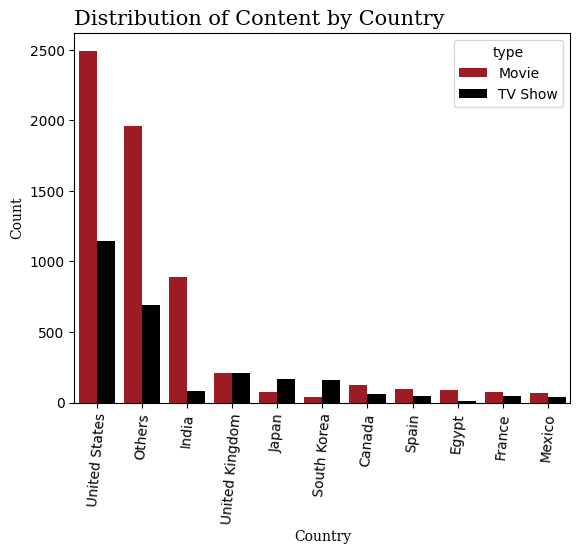

In [17]:
sns.barplot(data=df_grouped, x='countries_grouped', y='count', hue='type', palette=['#b20710', '#000000'])
plt.xticks(rotation=85)
plt.xlabel("Country", fontfamily='serif')
plt.ylabel("Count", fontfamily='serif')
plt.title("Distribution of Content by Country", loc='left', fontfamily='serif', fontsize=15, color='#000000')
plt.show()

- Insights:
  - Most countries produce movies more than tv shows, exception here is japan and south korea mainly beacuse they have animes and k-drama
  - Top contributed countries are USA, India


In [18]:
types_count = df.groupby(['release_year','type']).size().reset_index(name='count')
types_count = types_count[types_count['release_year'] >= 2000]
# here we grouped the release year with count of types for each year in the 2000s

In [19]:
fig = px.line(types_count, x='release_year', y='count', color='type',
        title='Netflix Growth in 2000s', markers=True, 
        color_discrete_map={'Movie':'#b20710', 'TV Show':'#000000'}, template='plotly_white')
fig.show()

- Insights:
    - after 2015 there is a noticable increase production count in both types
    - 2018 was the peak year for netflix production
    - after 2018 production count in Movies decreased
    - after 2020 TV Shows count decreased

In [20]:
#mapping rating data for easy reading
maping_data = {
    'TV-PG': 'Older Kids',
    'TV-MA': 'Adults',
    'TV-Y7-FV': 'Older Kids',
    'TV-Y7': 'Older Kids',
    'TV-14': 'Teens',
    'R': 'Adults',
    'TV-Y': 'Kids',
    'NR': 'Adults',
    'PG-13': 'Teens',
    'TV-G': 'Kids',
    'PG': 'Older Kids',
    'G': 'Kids',
    'UR': 'Adults',
    'NC-17': 'Adults'
}
df['rating'] = df['rating'].map(maping_data)
df['rating']

0            Teens
1           Adults
2           Adults
3           Adults
4           Adults
           ...    
8802        Adults
8803    Older Kids
8804        Adults
8805    Older Kids
8806         Teens
Name: rating, Length: 8790, dtype: object

In [21]:
rating_count = df.groupby(['rating', 'type']).size().reset_index(name='count').sort_values(by='count', ascending=False)
rating_count

,rating,type,count
0,Adults,Movie,2940
6,Teens,Movie,1917
1,Adults,TV Show,1149
4,Older Kids,Movie,971
7,Teens,TV Show,730
5,Older Kids,TV Show,516
2,Kids,Movie,298
3,Kids,TV Show,269


In [22]:
fig_rating = px.bar(rating_count, x='rating', y='count', color='type',
             title='Rating Distribution', barmode='group', text_auto=True,
             color_discrete_map={'Movie':'#b20710', 'TV Show':'#000000'}, template='plotly_white')
fig_rating.show()

- Insights:
    - the same as we notice before movie production is higher than tv shows
    - Most Netflix production is addressed to adutls then Teens

In [23]:
#list each genre in a seperate row
df['genre'] = df['listed_in'].str.split(', ')
df_genres = df.explode('genre')
df_genres['genre'].nunique()


42

In [24]:
#42 genre is too much for a visual so we will take the top 10
top_genres = df_genres['genre'].value_counts().head(10).reset_index().sort_values(by='count')


In [25]:
fig_genre = px.bar(top_genres, x='count', y='genre',
                   title='Top 10 Genres on Netflix', text_auto=True,
                   color_discrete_sequence=['#b20710'], template='plotly_white')
fig_genre.show()

In [26]:
df_cast = df[df['cast'] != 'No Data'].copy()
df_cast['actor'] = df_cast['cast'].str.split(',')
df_cast = df_cast.explode('actor')


In [27]:
top_10_actors = df_cast['actor'].value_counts().head(10).reset_index().sort_values(by='count')
top_10_actors.columns = ['Actor', 'Appearance Count']

In [28]:
fig_actor = px.bar(top_10_actors, x='Appearance Count', y='Actor', 
                    title='Top 10 Actors with Most Appearances', text_auto=True,
                    color_discrete_sequence=['#b20710'], template='plotly_white')
fig_actor.show()

In [29]:
df_director = df[df['director'] != 'No Data'].copy()
df_director['director_single'] = df['director'].str.split(',')
df_director = df_director.explode('director_single')
df_director['director_single'].nunique()

5118

In [30]:
top_10_directors = df_director['director_single'].value_counts().head(10).reset_index().sort_values(by='count')
top_10_directors.columns = ['Director', 'Number of Shows']

In [31]:
fig_dir = px.bar(top_10_directors, x='Number of Shows', y='Director', 
                    title='Top 10 Directors with Most Productions', text_auto=True,
                    color_discrete_sequence=['#b20710'], template='plotly_white')
fig_dir.show()

In [32]:
df_movies = df[df['type'] == 'Movie'].copy()

df_movies['duration_min'] = df_movies['duration'].str.replace(' min', '').astype(int)

fig_dist = px.histogram(df_movies, x='duration_min', nbins=50,
                       title='Distribution of Movie Durations',
                       labels={'duration_min': 'Duration (Minutes)'},
                       color_discrete_sequence=['#b20710'], template='plotly_white')
fig_dist.show()

-  90-110 minutes is the optimal content length for Netflix original movies

In [33]:
df_tv = df[df['type'] == 'TV Show'].copy()
df_tv['seasons'] = df_tv['duration'].str.split(' ').str[0].astype(int)

long_shows = df_tv[df_tv['seasons'] > 3].shape[0]
print(f"Only {long_shows} shows made it past 3 seasons!")

Only 254 shows made it past 3 seasons!


In [34]:
df_tv = df[df['type'] == 'TV Show'].copy()
df_tv['seasons'] = df_tv['duration'].str.split(' ').str[0].astype(int)

total_tv_shows = len(df_tv)
long_running_shows = len(df_tv[df_tv['seasons'] > 1])
long_shows_3 = df_tv[df_tv['seasons'] > 3].shape[0]
percentage = (long_running_shows / total_tv_shows) * 100

print(f"Total TV Shows: {total_tv_shows}")
print(f"Shows with more than 1 season: {long_running_shows}")
print(f"Percentage of long-running shows: {percentage:.2f}%")
print(f"Only {long_shows_3} shows made it past 3 seasons!")


Total TV Shows: 2664
Shows with more than 1 season: 873
Percentage of long-running shows: 32.77%
Only 254 shows made it past 3 seasons!
